# Notebook 13 — Neural Network Fraud Detection
## MLP → Embedding-Based Neural Network → Final Neural Champion

This notebook focuses only on neural models. Earlier tree-model experiments are not repeated.

**Primary metric:** PR-AUC / Average Precision.

**Development split:** stratified random 70/15/15.

**Final evaluation:** locked test set, used once after model/threshold selection.

In [1]:
from pathlib import Path
import sys
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

from sklearn.model_selection import train_test_split
from sklearn.metrics import average_precision_score, roc_auc_score, precision_recall_curve

ROOT = Path.cwd()
if not (ROOT / "src").exists() and (ROOT.parent / "src").exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / "src"))

from supervised_fraud import (
    BASE_REQUIRED, TARGET, SEED, set_seed,
    FraudFeatureTransformer,
    make_mlp_matrix, train_mlp, predict_mlp,
    fit_embedding_maps, encode_embeddings,
    make_embedding_numeric, train_embedding, predict_embedding,
    evaluate_model, select_threshold, NeuralFraudArtifact,
    save_artifact, HIGH_CARD, LOW_CARD
)

set_seed(SEED)
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", DEVICE)

Device: cpu


## 1. Load data

In [2]:
FRAUD_PATH = ROOT / "data" / "raw" / "Fraud_Data.csv"
IP_PATH = ROOT / "data" / "raw" / "IpAddress_to_Country.csv"

fraud = pd.read_csv(FRAUD_PATH)
ip_map = pd.read_csv(IP_PATH)

for col in ["signup_time", "purchase_time"]:
    fraud[col] = pd.to_datetime(fraud[col], errors="coerce", utc=True)

print("Fraud data:", fraud.shape)
print("IP map:", ip_map.shape)
display(fraud.head())

Fraud data: (151112, 11)
IP map: (138846, 3)


,user_id,signup_time,purchase_time,purchase_value,device_id,source,browser,sex,age,ip_address,class
0,22058,2015-02-24 22:55:49+00:00,2015-04-18 02:47:11+00:00,34,QVPSPJUOCKZAR,SEO,Chrome,M,39,7.327584e+08,0
1,333320,2015-06-07 20:39:50+00:00,2015-06-08 01:38:54+00:00,16,EOGFQPIZPYXFZ,Ads,Chrome,F,53,3.503114e+08,0
2,1359,2015-01-01 18:52:44+00:00,2015-01-01 18:52:45+00:00,15,YSSKYOSJHPPLJ,SEO,Opera,M,53,2.621474e+09,1
3,150084,2015-04-28 21:13:25+00:00,2015-05-04 13:54:50+00:00,44,ATGTXKYKUDUQN,SEO,Safari,M,41,3.840542e+09,0
4,221365,2015-07-21 07:09:52+00:00,2015-09-09 18:40:53+00:00,39,NAUITBZFJKHWW,Ads,Safari,M,45,4.155831e+08,0


## 2. Data audit and temporal distribution

In [3]:
display(
    fraud[BASE_REQUIRED + [TARGET]]
    .isna().sum()
    .sort_values(ascending=False)
    .to_frame("missing")
)

display(fraud[TARGET].value_counts().rename("count").to_frame())
print("Overall fraud rate:", fraud[TARGET].mean())

monthly = (
    fraud.assign(month=fraud["purchase_time"].dt.to_period("M").astype(str))
    .groupby("month")[TARGET]
    .agg(["count", "sum"])
)
monthly["fraud_rate"] = monthly["sum"] / monthly["count"]
display(monthly)

,missing
user_id,0
signup_time,0
purchase_time,0
purchase_value,0
device_id,0
source,0
browser,0
sex,0
age,0
ip_address,0


,count
class,
0,136961
1,14151


Overall fraud rate: 0.09364577267192546


,count,sum,fraud_rate
month,,,
2015-01,10097,7723,0.764881
2015-02,6449,291,0.045123
2015-03,12090,545,0.045079
2015-04,16551,740,0.044710
2015-05,19364,921,0.047562
2015-06,18908,842,0.044531
2015-07,19507,900,0.046137
2015-08,18662,833,0.044636
2015-09,14347,663,0.046212


## 3. Stratified 70/15/15 split

The earlier chronological experiment showed severe distribution shift.
For neural model development we therefore use a stratified random split so
train/validation/test preserve the overall class distribution.

In [4]:
train_df, temp_df = train_test_split(
    fraud, test_size=0.30, stratify=fraud[TARGET], random_state=SEED
)
val_df, test_df = train_test_split(
    temp_df, test_size=0.50, stratify=temp_df[TARGET], random_state=SEED
)

def split_summary(name, df):
    return {
        "split": name,
        "rows": len(df),
        "fraud": int(df[TARGET].sum()),
        "fraud_rate": float(df[TARGET].mean())
    }

display(pd.DataFrame([
    split_summary("Train", train_df),
    split_summary("Validation", val_df),
    split_summary("Test", test_df)
]))

,split,rows,fraud,fraud_rate
0,Train,105778,9906,0.093649
1,Validation,22667,2123,0.093660
2,Test,22667,2122,0.093616


## 4. Leakage-safe feature engineering

In [5]:
X_train = train_df[BASE_REQUIRED].copy()
y_train = train_df[TARGET].astype(int).to_numpy()

X_val = val_df[BASE_REQUIRED].copy()
y_val = val_df[TARGET].astype(int).to_numpy()

X_test = test_df[BASE_REQUIRED].copy()
y_test = test_df[TARGET].astype(int).to_numpy()

feature_builder = FraudFeatureTransformer(ip_map=ip_map)
F_train = feature_builder.fit_transform(X_train)
F_val = feature_builder.transform(X_val)
F_test = feature_builder.transform(X_test)

print("Features:", list(F_train.columns))
display(F_train.head())

Features: ['purchase_value', 'value_log1p', 'age', 'account_age_hours', 'purchase_hour', 'purchase_dow', 'purchase_month', 'purchase_day', 'is_weekend', 'user_frequency', 'device_frequency', 'ip_frequency', 'user_device_frequency', 'user_ip_frequency', 'device_ip_frequency', 'value_vs_train_median', 'value_above_train_p95', 'value_above_train_p99', 'ip_country', 'source', 'browser', 'sex', 'user_id', 'device_id', 'ip_address']


,purchase_value,value_log1p,age,account_age_hours,purchase_hour,purchase_dow,purchase_month,purchase_day,is_weekend,user_frequency,...,value_vs_train_median,value_above_train_p95,value_above_train_p99,ip_country,source,browser,sex,user_id,device_id,ip_address
61049,42,3.761200,31,1578.169722,0,0,9,28,0.0,1,...,1.200000,0.0,0.0,France,Ads,Chrome,F,249239,ITADJZEIXTLNN,1405681849.52253
141787,38,3.663562,32,1088.506667,4,2,8,26,0.0,1,...,1.085714,0.0,0.0,United Kingdom,Ads,Chrome,M,99761,RONUEMQKYSTOP,869534994.648238
84407,12,2.564949,36,1097.762500,5,3,6,4,0.0,1,...,0.342857,0.0,0.0,France,SEO,Safari,M,301394,NMAXHXENBTFPJ,1331686349.22515
115800,12,2.564949,19,37.645278,23,1,7,28,0.0,1,...,0.342857,0.0,0.0,United States,SEO,IE,M,168756,KYFZZRKEBAGNL,2553889459.92511
61857,41,3.737670,28,376.345278,12,1,2,10,0.0,1,...,1.171429,0.0,0.0,United States,SEO,Chrome,F,243337,RAZYKEIEAUQPD,2888344524.01516


## 5. MLP input construction

In [6]:
Xtr_mlp, mlp_scaler, mlp_low_maps = make_mlp_matrix(F_train, fit=True)
Xv_mlp, _, _ = make_mlp_matrix(
    F_val, scaler=mlp_scaler, maps=mlp_low_maps, fit=False
)
Xt_mlp, _, _ = make_mlp_matrix(
    F_test, scaler=mlp_scaler, maps=mlp_low_maps, fit=False
)

print("MLP matrix:", Xtr_mlp.shape)

MLP matrix: (105778, 206)


## 6. Tune the MLP

In [7]:
mlp_configs = [
    {
        "hidden": (64, 32), "dropout": 0.20, "lr": 1e-3,
        "weight_decay": 1e-4, "batch_size": 1024,
        "epochs": 25, "patience": 5
    },
    {
        "hidden": (128, 64), "dropout": 0.20, "lr": 1e-3,
        "weight_decay": 1e-4, "batch_size": 1024,
        "epochs": 30, "patience": 5
    },
    {
        "hidden": (128, 64), "dropout": 0.35, "lr": 5e-4,
        "weight_decay": 1e-4, "batch_size": 1024,
        "epochs": 30, "patience": 5
    },
    {
        "hidden": (256, 128), "dropout": 0.25, "lr": 5e-4,
        "weight_decay": 1e-4, "batch_size": 1024,
        "epochs": 30, "patience": 5
    },
]

mlp_results, mlp_models = [], {}

for i, config in enumerate(mlp_configs, 1):
    model, _, epoch, device = train_mlp(
        Xtr_mlp, y_train, Xv_mlp, y_val,
        config=config, seed=SEED+i, device=DEVICE
    )
    p = predict_mlp(model, Xv_mlp, device)
    metrics = evaluate_model(y_val, p, 0.5)
    metrics.update({"config_id": i, "best_epoch": epoch, "config": config})
    mlp_results.append(metrics)
    mlp_models[i] = (model, device)

mlp_results_df = pd.DataFrame(mlp_results).sort_values(
    "pr_auc", ascending=False
)
display(
    mlp_results_df[
        ["config_id", "pr_auc", "roc_auc", "best_epoch", "config"]
    ]
)

,config_id,pr_auc,roc_auc,best_epoch,config
3,4,0.690064,0.828716,11,"{'hidden': (256, 128), 'dropout': 0.25, 'lr': ..."
2,3,0.689214,0.823620,14,"{'hidden': (128, 64), 'dropout': 0.35, 'lr': 0..."
1,2,0.685299,0.825073,8,"{'hidden': (128, 64), 'dropout': 0.2, 'lr': 0...."
0,1,0.685182,0.819039,4,"{'hidden': (64, 32), 'dropout': 0.2, 'lr': 0.0..."


## 7. Best MLP

In [8]:
best_mlp_row = mlp_results_df.iloc[0]
best_mlp_id = int(best_mlp_row["config_id"])
best_mlp_model, best_mlp_device = mlp_models[best_mlp_id]
best_mlp_p_val = predict_mlp(
    best_mlp_model, Xv_mlp, best_mlp_device
)

print("Best MLP:", best_mlp_row["config"])
print("Validation PR-AUC:", best_mlp_row["pr_auc"])

Best MLP: {'hidden': (256, 128), 'dropout': 0.25, 'lr': 0.0005, 'weight_decay': 0.0001, 'batch_size': 1024, 'epochs': 30, 'patience': 5}
Validation PR-AUC: 0.6900639475038008


## 8. Embedding-based neural network

High-cardinality entities are represented with learned embeddings rather than
one-hot vectors:

`user_id`, `device_id`, `ip_address`, `source`, `browser`, `sex`, `ip_country`.

The embeddings are combined with standardized numerical/behavioral features.

In [9]:
embedding_maps = fit_embedding_maps(F_train)

Xtr_cat = encode_embeddings(F_train, embedding_maps)
Xv_cat = encode_embeddings(F_val, embedding_maps)
Xt_cat = encode_embeddings(F_test, embedding_maps)

Xtr_num, embedding_num_scaler = make_embedding_numeric(F_train, fit=True)
Xv_num, _ = make_embedding_numeric(
    F_val, scaler=embedding_num_scaler, fit=False
)
Xt_num, _ = make_embedding_numeric(
    F_test, scaler=embedding_num_scaler, fit=False
)

cardinalities = [
    len(embedding_maps[col]) + 1
    for col in HIGH_CARD + LOW_CARD
]

print("Embedding fields:", HIGH_CARD + LOW_CARD)
print("Cardinalities:", cardinalities)

Embedding fields: ['user_id', 'device_id', 'ip_address', 'source', 'browser', 'sex', 'ip_country']
Cardinalities: [105779, 97965, 100666, 4, 6, 3, 179]


## 9. Tune the embedding-based neural network

In [10]:
embedding_configs = [
    {
        "emb_dims": [8, 8, 8, 4, 4, 2, 4],
        "hidden": (128, 64), "dropout": 0.20, "lr": 1e-3,
        "weight_decay": 1e-4, "batch_size": 1024,
        "epochs": 30, "patience": 5
    },
    {
        "emb_dims": [16, 16, 16, 4, 4, 2, 4],
        "hidden": (128, 64), "dropout": 0.25, "lr": 5e-4,
        "weight_decay": 1e-4, "batch_size": 1024,
        "epochs": 35, "patience": 5
    },
    {
        "emb_dims": [16, 16, 16, 8, 8, 2, 8],
        "hidden": (256, 128), "dropout": 0.25, "lr": 5e-4,
        "weight_decay": 1e-4, "batch_size": 1024,
        "epochs": 35, "patience": 5
    },
]

embedding_results, embedding_models = [], {}

for i, config in enumerate(embedding_configs, 1):
    model, _, epoch, device = train_embedding(
        Xtr_cat, Xtr_num, y_train,
        Xv_cat, Xv_num, y_val,
        cardinalities=cardinalities,
        config=config,
        seed=SEED+100+i,
        device=DEVICE
    )
    p = predict_embedding(model, Xv_cat, Xv_num, device)
    metrics = evaluate_model(y_val, p, 0.5)
    metrics.update({"config_id": i, "best_epoch": epoch, "config": config})
    embedding_results.append(metrics)
    embedding_models[i] = (model, device)

embedding_results_df = pd.DataFrame(
    embedding_results
).sort_values("pr_auc", ascending=False)

display(
    embedding_results_df[
        ["config_id", "pr_auc", "roc_auc", "best_epoch", "config"]
    ]
)

,config_id,pr_auc,roc_auc,best_epoch,config
1,2,0.679105,0.821341,12,"{'emb_dims': [16, 16, 16, 4, 4, 2, 4], 'hidden..."
0,1,0.676561,0.820291,7,"{'emb_dims': [8, 8, 8, 4, 4, 2, 4], 'hidden': ..."
2,3,0.674807,0.815172,11,"{'emb_dims': [16, 16, 16, 8, 8, 2, 8], 'hidden..."


## 10. Select the final neural champion

In [11]:
best_embedding_row = embedding_results_df.iloc[0]
best_embedding_id = int(best_embedding_row["config_id"])

best_embedding_model, best_embedding_device = (
    embedding_models[best_embedding_id]
)
best_embedding_p_val = predict_embedding(
    best_embedding_model,
    Xv_cat,
    Xv_num,
    best_embedding_device
)

if best_embedding_row["pr_auc"] > best_mlp_row["pr_auc"]:
    champion_type = "embedding"
    champion_model = best_embedding_model
    champion_device = best_embedding_device
    champion_p_val = best_embedding_p_val
    champion_config = best_embedding_row["config"]
else:
    champion_type = "mlp"
    champion_model = best_mlp_model
    champion_device = best_mlp_device
    champion_p_val = best_mlp_p_val
    champion_config = best_mlp_row["config"]

print("FINAL NEURAL CHAMPION:", champion_type)
print("Validation PR-AUC:", average_precision_score(y_val, champion_p_val))
print("Validation ROC-AUC:", roc_auc_score(y_val, champion_p_val))

FINAL NEURAL CHAMPION: mlp
Validation PR-AUC: 0.6900639475038008
Validation ROC-AUC: 0.8287163573779537


## 11. Validation threshold optimization

In [12]:
champion_threshold = select_threshold(y_val, champion_p_val)

validation_metrics = evaluate_model(
    y_val, champion_p_val, champion_threshold
)

display(pd.DataFrame([validation_metrics]))
print("Validation threshold:", champion_threshold)

,threshold,pr_auc,roc_auc,accuracy,precision,recall,f1,balanced_accuracy,tn,fp,fn,tp
0,0.937358,0.690064,0.828716,0.954383,0.978892,0.524258,0.682822,0.761545,20520,24,1010,1113


Validation threshold: 0.9373584389686584


## 12. Final refit on Train + Validation

The architecture and threshold are now fixed. Train + Validation become the
development dataset. A small internal stratified holdout is used only for
early stopping.

The external Test set remains locked.

In [13]:
dev_df = pd.concat([train_df, val_df], ignore_index=True)
X_dev = dev_df[BASE_REQUIRED].copy()
y_dev = dev_df[TARGET].astype(int).to_numpy()

final_feature_builder = FraudFeatureTransformer(ip_map=ip_map)
F_dev = final_feature_builder.fit_transform(X_dev)
F_test_final = final_feature_builder.transform(
    test_df[BASE_REQUIRED].copy()
)

dev_train_idx, dev_holdout_idx = train_test_split(
    np.arange(len(y_dev)),
    test_size=0.15,
    stratify=y_dev,
    random_state=SEED
)

if champion_type == "mlp":
    Xdev, final_scaler, final_maps = make_mlp_matrix(F_dev, fit=True)
    Xtest, _, _ = make_mlp_matrix(
        F_test_final,
        scaler=final_scaler,
        maps=final_maps,
        fit=False
    )

    final_model, _, final_epoch, final_device = train_mlp(
        Xdev[dev_train_idx], y_dev[dev_train_idx],
        Xdev[dev_holdout_idx], y_dev[dev_holdout_idx],
        config=champion_config,
        seed=SEED+999,
        device=DEVICE
    )

    final_test_probabilities = predict_mlp(
        final_model, Xtest, final_device
    )

    artifact_metadata = {
        "scaler": final_scaler,
        "low_maps": final_maps,
        "device": final_device,
        "threshold": champion_threshold,
        "config": champion_config,
        "best_epoch": final_epoch,
    }

else:
    final_embedding_maps = fit_embedding_maps(F_dev)

    Xdev_cat = encode_embeddings(F_dev, final_embedding_maps)
    Xtest_cat = encode_embeddings(F_test_final, final_embedding_maps)

    Xdev_num, final_num_scaler = make_embedding_numeric(
        F_dev, fit=True
    )
    Xtest_num, _ = make_embedding_numeric(
        F_test_final, scaler=final_num_scaler, fit=False
    )

    final_cardinalities = [
        len(final_embedding_maps[col]) + 1
        for col in HIGH_CARD + LOW_CARD
    ]

    final_model, _, final_epoch, final_device = train_embedding(
        Xdev_cat[dev_train_idx],
        Xdev_num[dev_train_idx],
        y_dev[dev_train_idx],
        Xdev_cat[dev_holdout_idx],
        Xdev_num[dev_holdout_idx],
        y_dev[dev_holdout_idx],
        cardinalities=final_cardinalities,
        config=champion_config,
        seed=SEED+999,
        device=DEVICE
    )

    final_test_probabilities = predict_embedding(
        final_model,
        Xtest_cat,
        Xtest_num,
        final_device
    )

    artifact_metadata = {
        "embedding_maps": final_embedding_maps,
        "numeric_scaler": final_num_scaler,
        "device": final_device,
        "threshold": champion_threshold,
        "config": champion_config,
        "best_epoch": final_epoch,
    }

print("Final refit complete.")

Final refit complete.


## 13. LOCKED Test evaluation

In [14]:
test_metrics = evaluate_model(
    y_test,
    final_test_probabilities,
    champion_threshold
)

display(pd.DataFrame([test_metrics]))
print("Test was not used for model selection or threshold selection.")

,threshold,pr_auc,roc_auc,accuracy,precision,recall,f1,balanced_accuracy,tn,fp,fn,tp
0,0.937358,0.695629,0.829392,0.955927,0.979505,0.540528,0.696629,0.76968,20521,24,975,1147


Test was not used for model selection or threshold selection.


## 14. Precision-recall curve

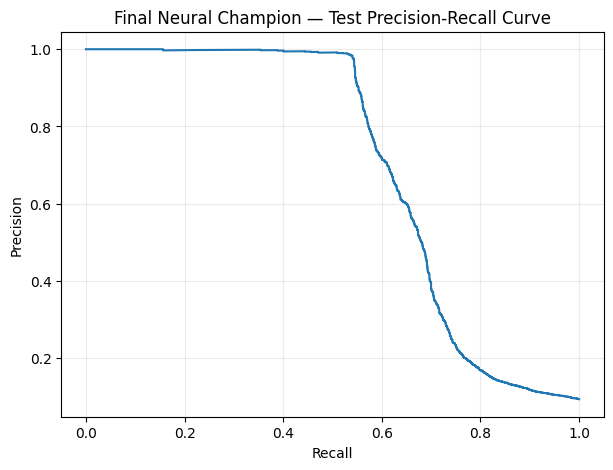

In [15]:
precision, recall, _ = precision_recall_curve(
    y_test, final_test_probabilities
)

plt.figure(figsize=(7, 5))
plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Final Neural Champion — Test Precision-Recall Curve")
plt.grid(alpha=0.25)
plt.show()

## 15. Save the complete inference artifact

In [16]:
artifact = NeuralFraudArtifact(
    feature_transformer=final_feature_builder,
    model_type=champion_type,
    model=final_model,
    metadata=artifact_metadata
)

artifact_path = ROOT / "artifacts" / "final_supervised_neural_model.joblib"
save_artifact(artifact, artifact_path)

print("Saved:", artifact_path)
print("Champion:", champion_type)
print("Threshold:", champion_threshold)

Saved: d:\fraud_ecommerce_graph_anomaly_and_ml\artifacts\final_supervised_neural_model.joblib
Champion: mlp
Threshold: 0.9373584389686584


In [17]:
import sys
print(sys.executable)
print(sys.version)

c:\Users\devar\AppData\Local\Programs\Python\Python312\python.exe
3.12.10 (tags/v3.12.10:0cc8128, Apr  8 2025, 12:21:36) [MSC v.1943 64 bit (AMD64)]


In [18]:
import torch
print(torch.__version__)
print(torch.__file__)

2.12.1+cpu
c:\Users\devar\AppData\Local\Programs\Python\Python312\Lib\site-packages\torch\__init__.py


In [19]:
test_results = test_df[BASE_REQUIRED + [TARGET]].copy()

test_results["fraud_probability"] = final_test_probabilities
test_results["predicted_class"] = (
    final_test_probabilities >= champion_threshold
).astype(int)

test_results["actual_class"] = test_results[TARGET].astype(int)

test_results = test_results.drop(columns=[TARGET])

test_results_path = ROOT / "artifacts" / "final_test_predictions.csv"
test_results.to_csv(test_results_path, index=False)

print("Saved:", test_results_path)
print("Rows:", len(test_results))

Saved: d:\fraud_ecommerce_graph_anomaly_and_ml\artifacts\final_test_predictions.csv
Rows: 22667


## 16. Final conclusion

**MLP tuning → Embedding-NN tuning → validation PR-AUC selection →
validation threshold → Train+Validation refit → locked Test → artifact**

The artifact contains the feature transformer, learned encodings/scalers,
neural model and threshold needed for raw-transaction scoring in Streamlit.